# Diffuse K - investigations for cloud parameterization

In [1]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import pandas as pd
import os

In [2]:
save_dir = '../manuscript-2025/modeled-station-data'
save_dirm1 = '../manuscript-2025/m1-dir-dif'

m1_dsw3 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw3.nc'))
m1_dsw1 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw1.nc'))
m1_dsw30 = xr.open_dataset(os.path.join(save_dir, 'm1_dsw30.nc'))
m1_k = xr.open_dataset(os.path.join(save_dir, 'm1_k.nc'))
m1_ghi = xr.open_dataset(os.path.join(save_dir, 'm1_ghi.nc'))
m1_dir22 = xr.open_dataset(os.path.join(save_dirm1, 'm1_dir_22.nc'))
m1_dif22 = xr.open_dataset(os.path.join(save_dirm1, 'm1_dif_22.nc'))

In [3]:
# STATION DATA
save_dir = '../manuscript-2025/station-data'

# SAIL M1 QCRAD LONG
subset_sw_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_sw.nc'))
subset_dif_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_diff.nc'))
subset_dir_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dir.nc'))
subset_best_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_best_sw.nc'))
subset_zenith_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_zen.nc'))
sub_dirh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_dirh.nc'))
sub_difh_hourly = xr.open_dataset(os.path.join(save_dir, 'm1qc_difh_xx.nc'))
sub_dirh_hourly = sub_dirh_hourly['__xarray_dataarray_variable__'].rename('short_direct_normal').to_dataset()

# SAIL M1 & S3
m1_sw_hourly_sail = xr.open_dataset(os.path.join(save_dir, 'm1_sw.nc'))

In [4]:
# ADD time selection and rolling

## Modeled K patterns

In [5]:
# modeled K
m1_k['k']

<xarray.DataArray 'k' (time: 7320)> Size: 29kB
[7320 values with dtype=float32]
Coordinates:
    x        float32 4B ...
    y        float32 4B ...
  * time     (time) datetime64[ns] 59kB 2021-09-30T06:00:00 ... 2022-08-01T05...
Attributes:
    units:         None
    description:   Fraction of diffuse/global in the visible
    grid_mapping:  projection

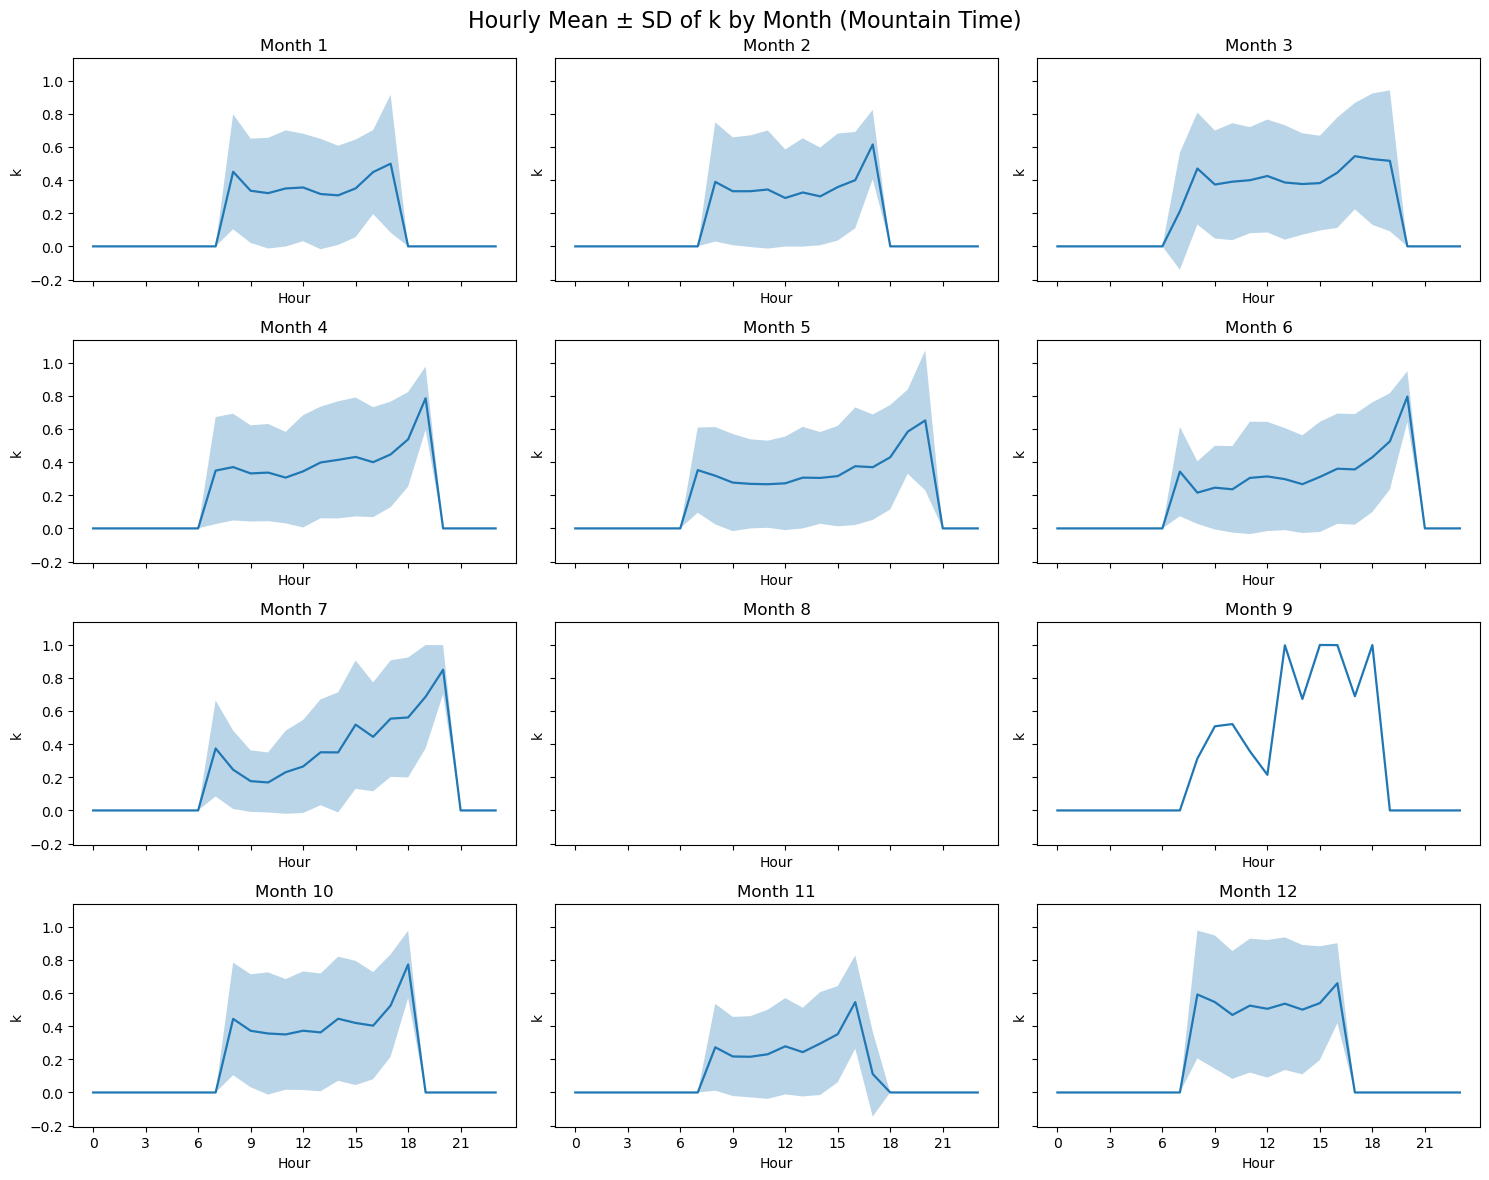

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# 1. Convert UTC → Mountain Time
mt_time = (
    pd.to_datetime(m1_k.time.values)
    .tz_localize("UTC")
    .tz_convert("US/Mountain")
)

# 2. Add month and hour
m1_k_local = m1_k.assign_coords(
    time_mt=("time", mt_time),
    month=("time", mt_time.month),
    hour=("time", mt_time.hour)
)

# 3. Group by (month, hour)
grouped = m1_k_local["k"].groupby(("month", "hour"))
k_mean_da = grouped.mean()
k_std_da  = grouped.std()

# 4. Convert multi-index to 12×24 matrices
mean_2d = k_mean_da.to_series().unstack().reindex(index=range(1,13), columns=range(24))
std_2d  = k_std_da.to_series().unstack().reindex(index=range(1,13), columns=range(24))

k_mean_array = mean_2d.values  # shape (12, 24)
k_std_array  = std_2d.values   # shape (12, 24)

# 5. Plot
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.ravel()

for m in range(12):
    ax = axes[m]
    ax.plot(range(24), k_mean_array[m], lw=1.6)
    ax.fill_between(
        range(24),
        k_mean_array[m] - k_std_array[m],
        k_mean_array[m] + k_std_array[m],
        alpha=0.3
    )
    ax.set_title(f"Month {m+1}")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("Hour")
    ax.set_ylabel("k")

fig.suptitle("Hourly Mean ± SD of k by Month (Mountain Time)", fontsize=16)
plt.tight_layout()
plt.show()


## Observed k

In [7]:
# observed k
m1_obs_k = sub_difh_hourly['__xarray_dataarray_variable__'] / subset_best_hourly['BestEstimate_down_short_hemisp']
m1_obs_k = m1_obs_k.rename('k').clip(min=0, max=1)
m1_obs_k

<xarray.DataArray 'k' (time: 15672)> Size: 63kB
array([0.22022824, 0.02272455, 0.        , ..., 0.6339764 , 0.5140423 ,
       0.5111428 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 125kB 2021-09-01 ... 2023-06-15T23:00:00

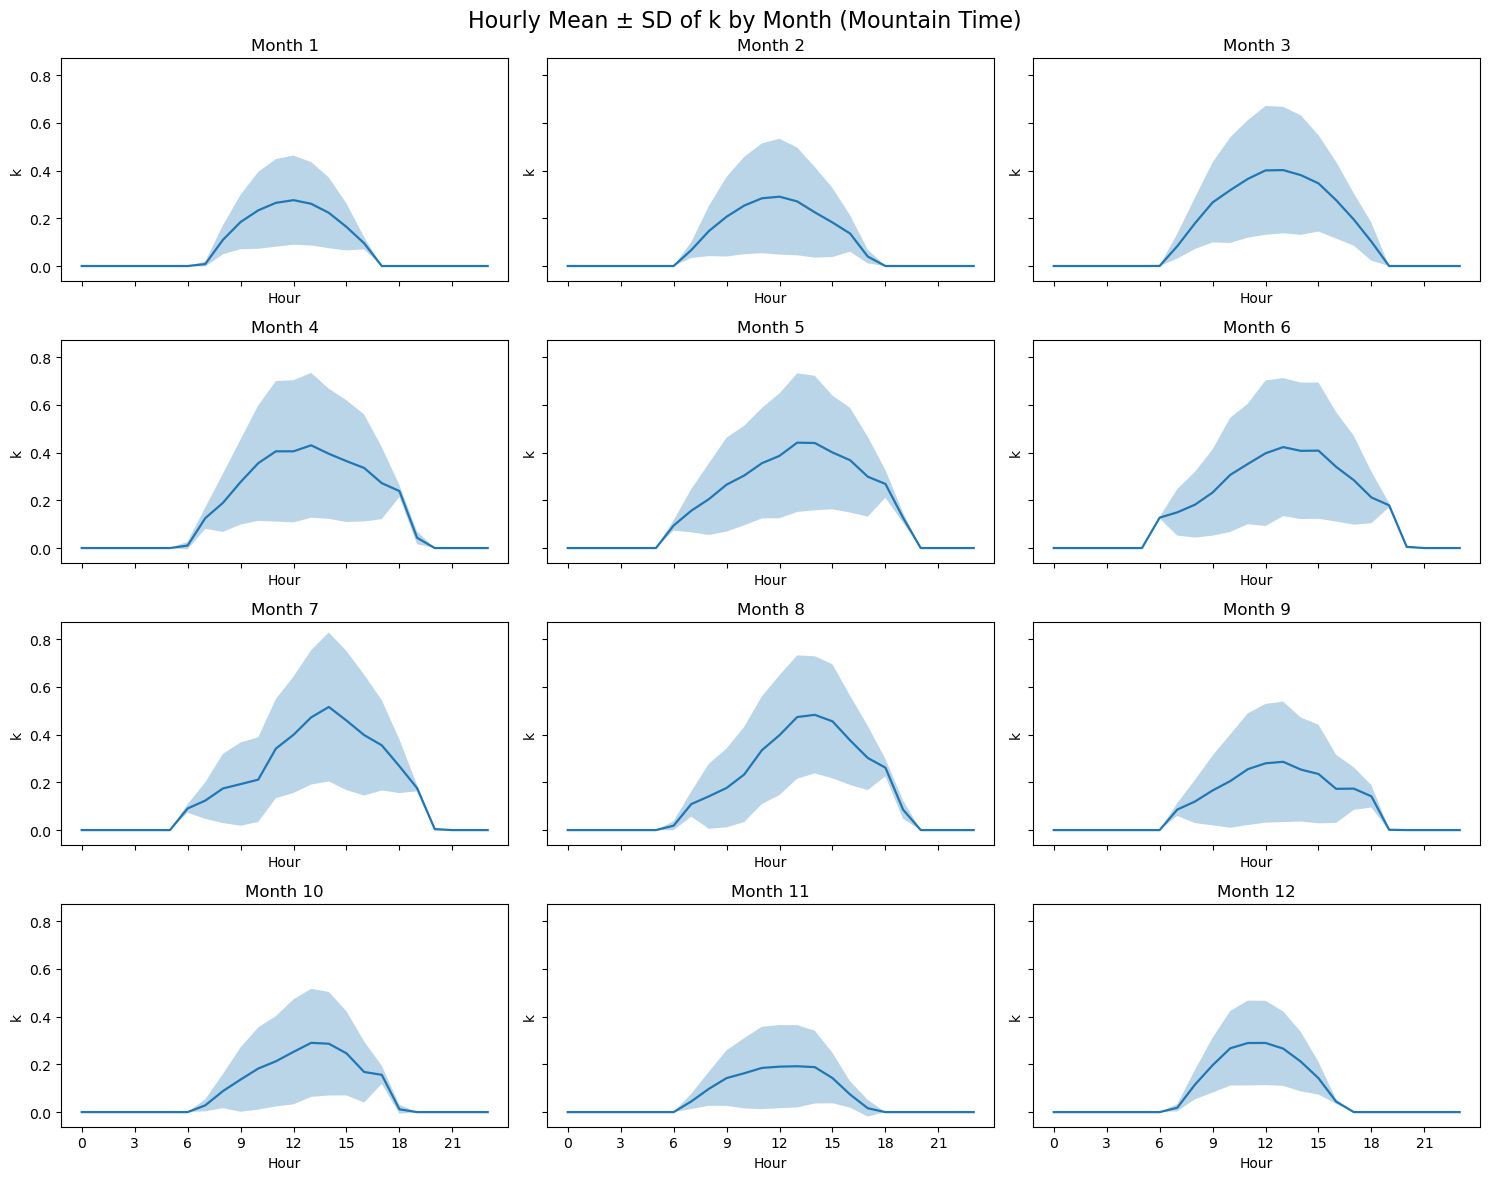

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# 1. Convert UTC → Mountain Time
mt_time = (
    pd.to_datetime(m1_obs_k.time.values)
    .tz_localize("UTC")
    .tz_convert("US/Mountain")
)

# 2. Add month and hour
m1_obs_k_local = m1_obs_k.assign_coords(
    time_mt=("time", mt_time),
    month=("time", mt_time.month),
    hour=("time", mt_time.hour)
)

# 3. Group by (month, hour)
grouped_obs = m1_obs_k_local.groupby(("month", "hour"))
k_obs_mean_da = grouped_obs.mean()
k_obs_std_da  = grouped_obs.std()

# 4. Convert multi-index to 12×24 matrices
mean_2d_obs = k_obs_mean_da.to_series().unstack().reindex(index=range(1,13), columns=range(24))
std_2d_obs  = k_obs_std_da.to_series().unstack().reindex(index=range(1,13), columns=range(24))

k_obs_mean_array = mean_2d_obs.values  # shape (12, 24)
k_obs_std_array  = std_2d_obs.values   # shape (12, 24)

# 5. Plot
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.ravel()

for m in range(12):
    ax = axes[m]
    ax.plot(range(24), k_obs_mean_array[m], lw=1.6)
    ax.fill_between(
        range(24),
        k_obs_mean_array[m] - k_obs_std_array[m],
        k_obs_mean_array[m] + k_obs_std_array[m],
        alpha=0.3
    )
    ax.set_title(f"Month {m+1}")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("Hour")
    ax.set_ylabel("k")

fig.suptitle("Hourly Mean ± SD of k by Month (Mountain Time)", fontsize=16)
plt.tight_layout()
plt.show()


ValueError: Axis limits cannot be NaN or Inf

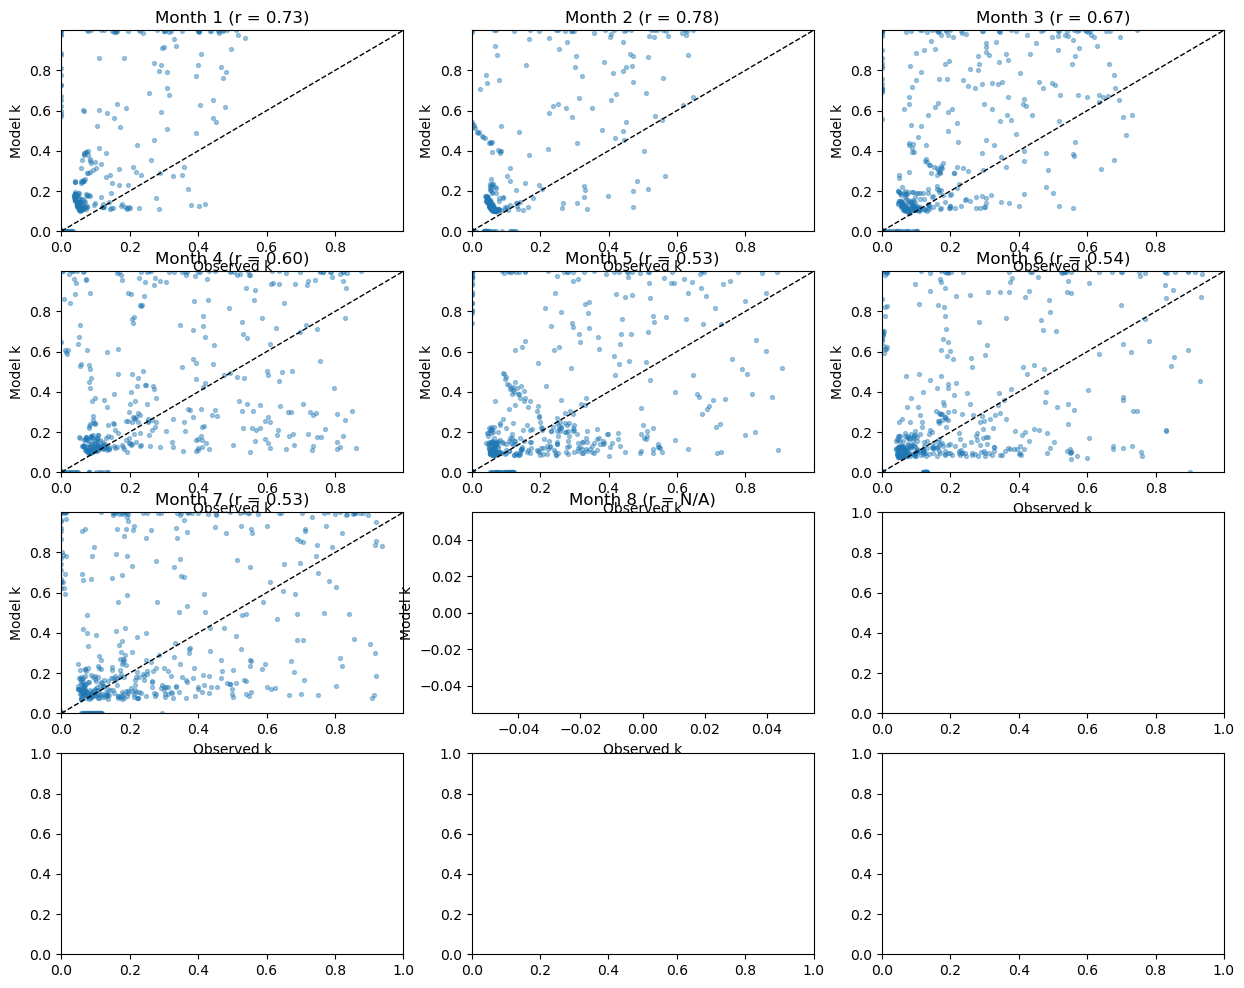

In [9]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import xarray as xr
# from scipy.stats import pearsonr

# # ----------------------------------------------------
# # 1. Convert both datasets to Mountain Time
# # ----------------------------------------------------
# def convert_to_mt(ds):
#     mt_time = (
#         pd.to_datetime(ds.time.values)
#         .tz_localize("UTC")
#         .tz_convert("US/Mountain")
#     )
#     return ds.assign_coords(
#         time_mt=("time", mt_time),
#         month=("time", mt_time.month),
#         hour=("time", mt_time.hour)
#     ).swap_dims({"time": "time_mt"}).drop_vars("time")

# m1_k_local      = convert_to_mt(m1_k)
# m1_obs_k_local  = convert_to_mt(m1_obs_k)

# # ----------------------------------------------------
# # 2. Resample both datasets to hourly mean
# # ----------------------------------------------------
# m1_k_hr      = m1_k_local.resample(time_mt="1h").mean()
# m1_obs_k_hr  = m1_obs_k_local.resample(time_mt="1h").mean()

# # ----------------------------------------------------
# # 3. Align model & obs on the same timestamps
# # ----------------------------------------------------
# m1_k_aligned, m1_obs_aligned = xr.align(m1_k_hr, m1_obs_k_hr, join="inner")

# # Extract k variables as Series
# k_model = m1_k_aligned["k"].to_series()
# k_obs   = m1_obs_aligned.to_series()

# # Combine into one DataFrame
# df = pd.DataFrame({"obs": k_obs, "model": k_model})
# df["month"] = df.index.month

# # ----------------------------------------------------
# # 4. Plot model (y) vs obs (x) for each month
# # ----------------------------------------------------
# fig, axes = plt.subplots(4, 3, figsize=(15, 12))
# axes = axes.ravel()

# for m in range(1, 13):
#     ax = axes[m-1]
#     sub = df[df["month"] == m].dropna()

#     if len(sub) > 2:
#         # compute correlation
#         r, _ = pearsonr(sub["obs"], sub["model"])
#         r_txt = f"r = {r:.2f}"
#     else:
#         r_txt = "r = N/A"

#     # scatter plot
#     ax.scatter(sub["obs"], sub["model"], s=8, alpha=0.4)

#     # 1:1 line
#     lims = [
#         min(sub["obs"].min(), sub["model"].min()),
#         max(sub["obs"].max(), sub["model"].max()),
#     ]
#     ax.plot(lims, lims, "k--", lw=1)

#     ax.set_title(f"Month {m} ({r_txt})")
#     ax.set_xlabel("Observed k")
#     ax.set_ylabel("Model k")
#     ax.set_xlim(lims)
#     ax.set_ylim(lims)

# plt.tight_layout()
# plt.show()


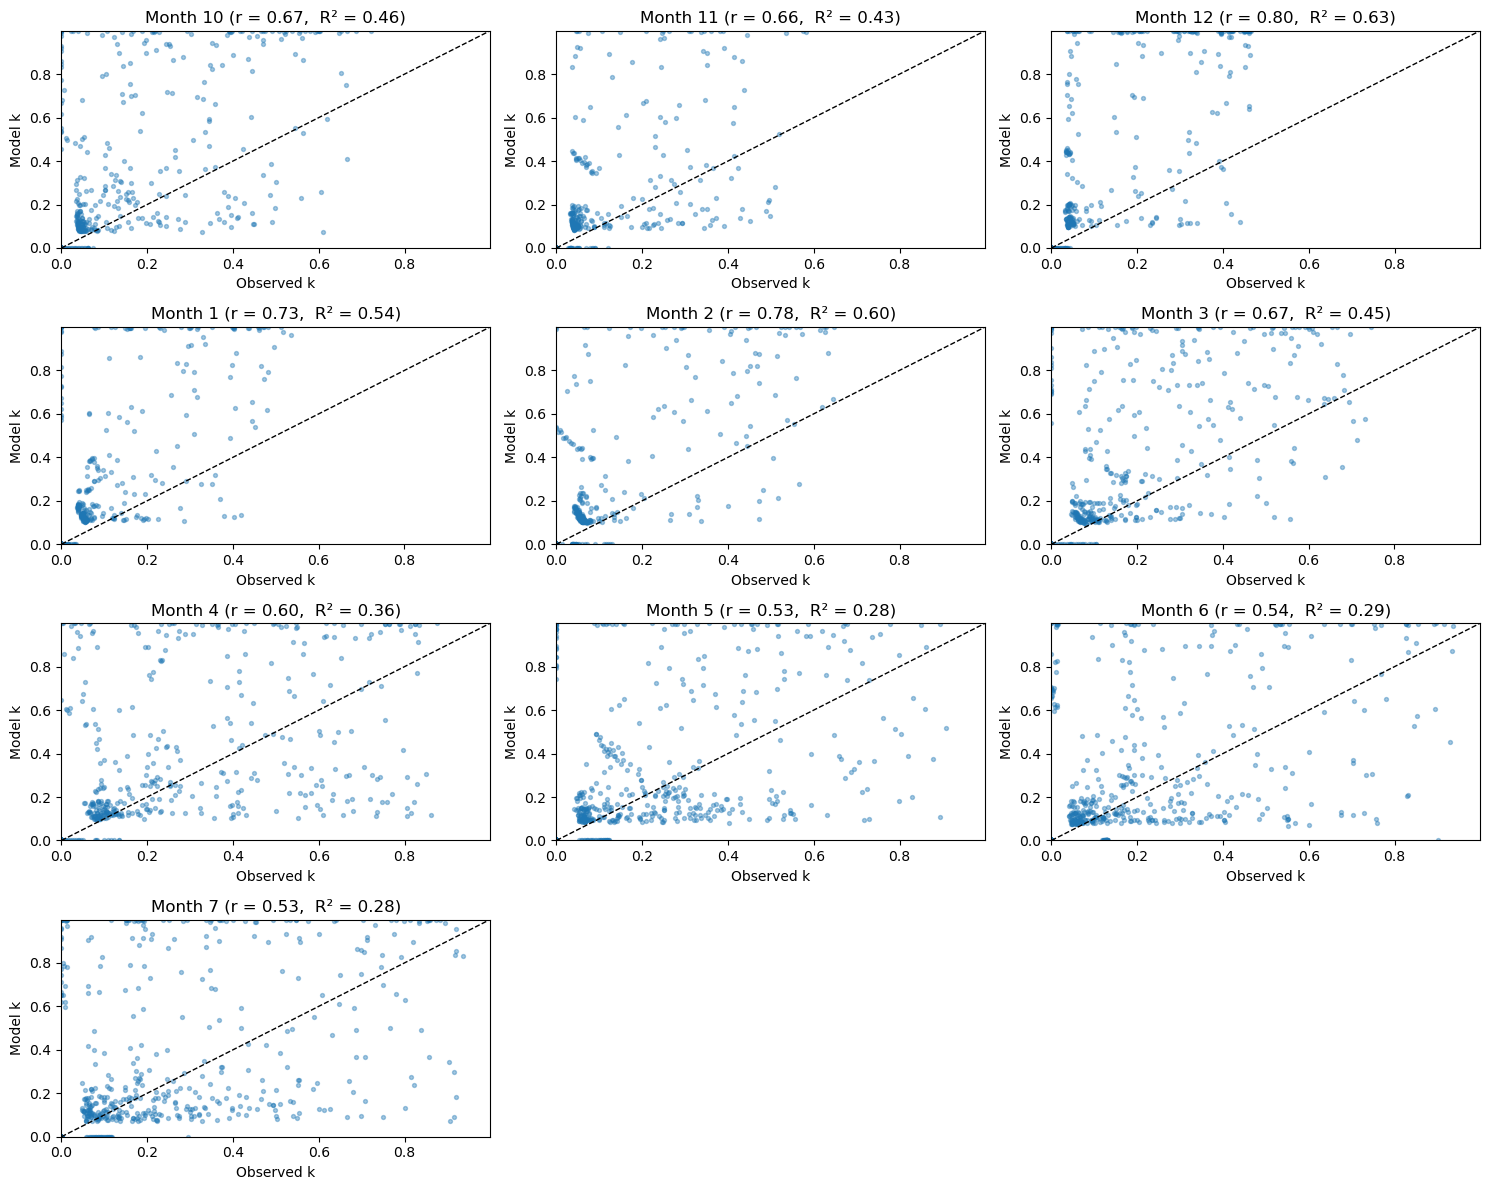

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.stats import pearsonr

# ----------------------------------------------------
# 1. Convert both datasets to Mountain Time
# ----------------------------------------------------
def convert_to_mt(ds):
    mt_time = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
    )
    return (
        ds.assign_coords(
            time_mt=("time", mt_time),
            month=("time", mt_time.month),
            hour=("time", mt_time.hour),
        )
        .swap_dims({"time": "time_mt"})
        .drop_vars("time")
    )

m1_k_local     = convert_to_mt(m1_k)
m1_obs_k_local = convert_to_mt(m1_obs_k)

# ----------------------------------------------------
# 2. Resample to hourly means
# ----------------------------------------------------
m1_k_hr      = m1_k_local.resample(time_mt="1h").mean()
m1_obs_k_hr  = m1_obs_k_local.resample(time_mt="1h").mean()

# ----------------------------------------------------
# 3. Align model & obs
# ----------------------------------------------------
m1_k_aligned, m1_obs_aligned = xr.align(m1_k_hr, m1_obs_k_hr, join="inner")

# ----------------------------------------------------
# 4. Extract model and obs
# ----------------------------------------------------
k_model = m1_k_aligned["k"].to_series()
k_obs   = m1_obs_aligned.to_series()

df = pd.DataFrame({"obs": k_obs, "model": k_model})
df["month"] = df.index.month

# ----------------------------------------------------
# 5. Drop months 8 and 9
# ----------------------------------------------------
df = df[~df["month"].isin([8, 9])]

# ----------------------------------------------------
# 6. Desired month order
# ----------------------------------------------------
month_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7]

# ----------------------------------------------------
# 7. Plot in desired order
# ----------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.ravel()

for i, m in enumerate(month_order):
    ax = axes[i]

    sub = df[df["month"] == m].dropna()

    # Compute correlation and R^2
    if len(sub) > 2:
        r, _ = pearsonr(sub["obs"], sub["model"])
        r2 = r**2
        stats_txt = f"r = {r:.2f},  R² = {r2:.2f}"
    else:
        stats_txt = "r = N/A, R² = N/A"

    # Scatter plot
    ax.scatter(sub["obs"], sub["model"], s=8, alpha=0.4)

    # 1:1 line
    if len(sub) > 0:
        lims = [
            min(sub["obs"].min(), sub["model"].min()),
            max(sub["obs"].max(), sub["model"].max()),
        ]
        ax.plot(lims, lims, "k--", lw=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)

    ax.set_title(f"Month {m} ({stats_txt})")
    ax.set_xlabel("Observed k")
    ax.set_ylabel("Model k")


# Hide unused subplots
for j in range(len(month_order), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


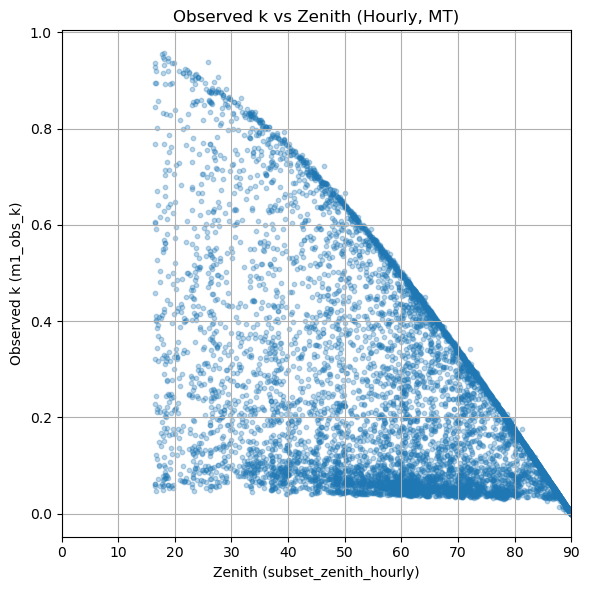

In [11]:
def convert_to_mt(ds):
    mt_time = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
    )
    return (
        ds.assign_coords(
            time_mt=("time", mt_time),
            month=("time", mt_time.month),
            hour=("time", mt_time.hour)
        )
        .swap_dims({"time": "time_mt"})
        .drop_vars("time")
    )

subset_zenith_local = convert_to_mt(subset_zenith_hourly)

subset_zenith_hr = subset_zenith_local.resample(time_mt="1h").mean()

subset_zenith_aligned, m1_obs_aligned_for_zen = xr.align(
    subset_zenith_hr,
    m1_obs_k_hr,
    join="inner"
)

zen = subset_zenith_aligned["zenith"].to_series()     # or whatever variable name is inside
k_obs_for_plot = m1_obs_aligned_for_zen.to_series()

plt.figure(figsize=(6,6))

plt.scatter(zen, k_obs_for_plot, s=10, alpha=0.3)

# 1:1 line (optional—you may not want it if units differ)
# lims = [
#     min(zen.min(), k_obs_for_plot.min()),
#     max(zen.max(), k_obs_for_plot.max())
# ]
# plt.plot(lims, lims, "k--", lw=1)
plt.xlim(0, 90)

plt.xlabel("Zenith (subset_zenith_hourly)")
plt.ylabel("Observed k (m1_obs_k)")
plt.title("Observed k vs Zenith (Hourly, MT)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
from scipy.stats import pearsonr

df_zen = pd.DataFrame({"zen": zen, "obs_k": k_obs_for_plot}).dropna()
r, _ = pearsonr(df_zen["zen"], df_zen["obs_k"])
r2 = r**2

print("Correlation r:", r)
print("R²:", r2)


Correlation r: -0.6700044675522387
R²: 0.44890598653995895


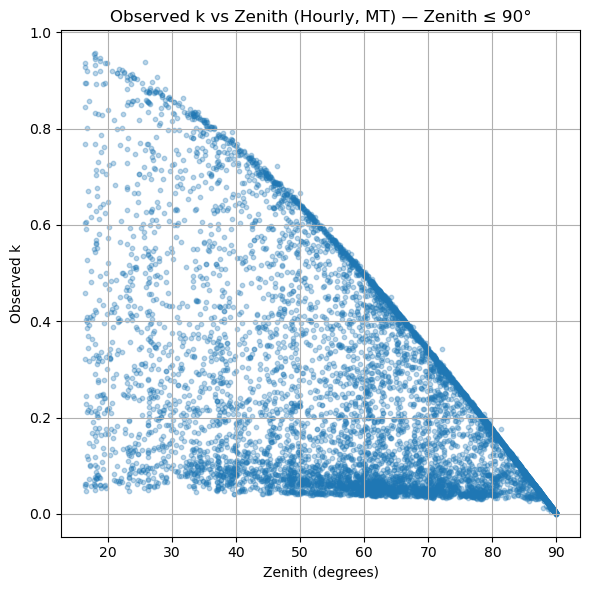

In [13]:
df_zen = pd.DataFrame({
    "zen": zen,
    "k_obs": k_obs_for_plot
}).dropna()

df_zen = df_zen[df_zen["zen"] <= 90]

plt.figure(figsize=(6,6))

plt.scatter(df_zen["zen"], df_zen["k_obs"], s=10, alpha=0.3)

plt.xlabel("Zenith (degrees)")
plt.ylabel("Observed k")
plt.title("Observed k vs Zenith (Hourly, MT) — Zenith ≤ 90°")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
from scipy.stats import pearsonr

r, _ = pearsonr(df_zen["zen"], df_zen["k_obs"])
r2 = r**2

print(f"r = {r:.2f}, R² = {r2:.2f}")


r = -0.49, R² = 0.24


### Inverse relationship - something wrong

In [15]:
def to_local_mt(ds):
    mt_time = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
    )
    return (
        ds.assign_coords(time_mt=("time", mt_time))
          .swap_dims({"time": "time_mt"})
          .drop_vars("time")
    )

subset_dif_local  = to_local_mt(subset_dif_hourly)
subset_dir_local  = to_local_mt(subset_dir_hourly)
subset_best_local = to_local_mt(subset_best_hourly)
subset_m1_obs_k = to_local_mt(m1_obs_k)


In [16]:
subset_m1_obs_k
subset_best_local

<xarray.Dataset> Size: 188kB
Dimensions:                         (time_mt: 15672)
Coordinates:
  * time_mt                         (time_mt) object 125kB 163045440000000000...
Data variables:
    BestEstimate_down_short_hemisp  (time_mt) float32 63kB ...

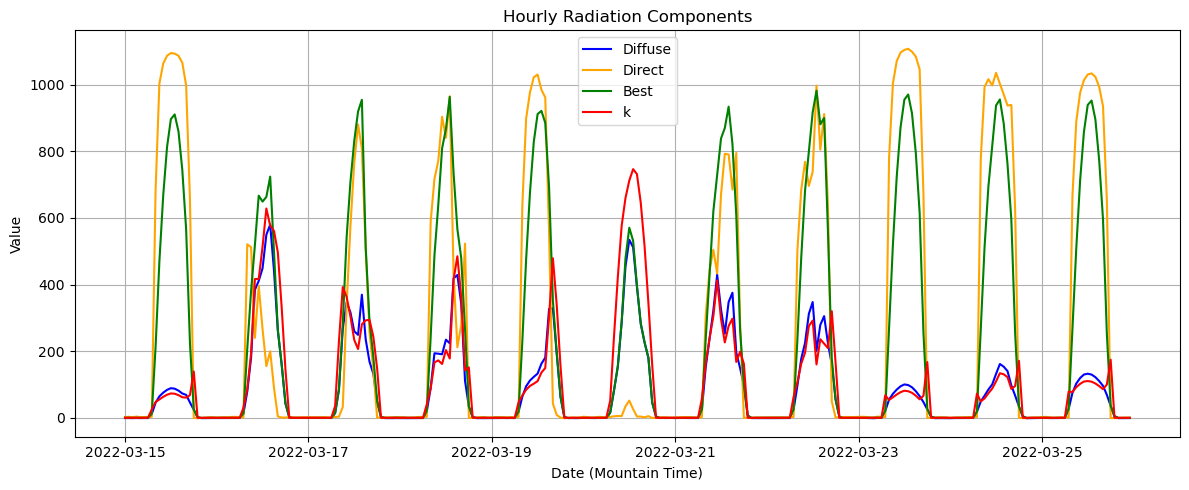

In [17]:
start = "2022-03-15"
end   = "2022-03-25"

subset_dif_sel  = subset_dif_local.sel(time_mt=slice(start, end))
subset_dir_sel  = subset_dir_local.sel(time_mt=slice(start, end))
subset_best_sel = subset_best_local.sel(time_mt=slice(start, end))
subset_k_sel = subset_m1_obs_k.sel(time_mt=slice(start, end))

dif = subset_dif_sel["down_short_diffuse_hemisp"].to_series()
dirr = subset_dir_sel["short_direct_normal"].to_series()
best = subset_best_sel["BestEstimate_down_short_hemisp"].to_series()
k_obs = subset_k_sel.to_series() * 1000

plt.figure(figsize=(12,5))

plt.plot(dif.index,  dif.values,  label="Diffuse",  color="blue")
plt.plot(dirr.index, dirr.values, label="Direct",   color="orange")
plt.plot(best.index, best.values, label="Best",     color="green")
plt.plot(k_obs.index, k_obs.values, label="k", 
         color="red")

plt.xlabel("Date (Mountain Time)")
plt.ylabel("Value")
plt.title("Hourly Radiation Components")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


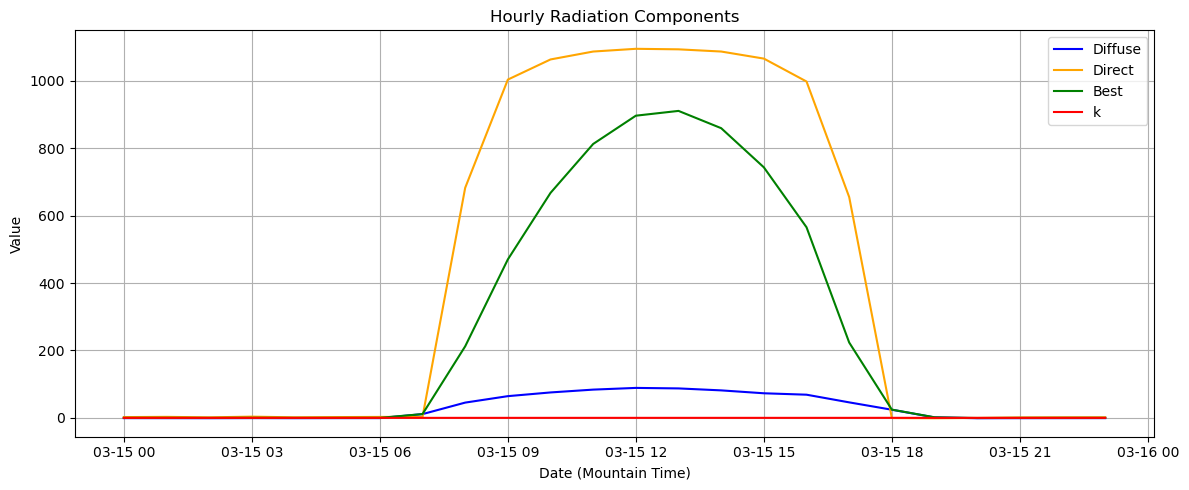

In [18]:
start = "2022-03-15"
end   = "2022-03-15"

subset_dif_sel  = subset_dif_local.sel(time_mt=slice(start, end))
subset_dir_sel  = subset_dir_local.sel(time_mt=slice(start, end))
subset_best_sel = subset_best_local.sel(time_mt=slice(start, end))
subset_k_sel = subset_m1_obs_k.sel(time_mt=slice(start, end))

dif = subset_dif_sel["down_short_diffuse_hemisp"].to_series()
dirr = subset_dir_sel["short_direct_normal"].to_series()
best = subset_best_sel["BestEstimate_down_short_hemisp"].to_series()
k_obs = subset_k_sel.to_series()

plt.figure(figsize=(12,5))

plt.plot(dif.index,  dif.values,  label="Diffuse",  color="blue")
plt.plot(dirr.index, dirr.values, label="Direct",   color="orange")
plt.plot(best.index, best.values, label="Best",     color="green")
plt.plot(k_obs.index, k_obs.values, label="k", 
         color="red")

plt.xlabel("Date (Mountain Time)")
plt.ylabel("Value")
plt.title("Hourly Radiation Components")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

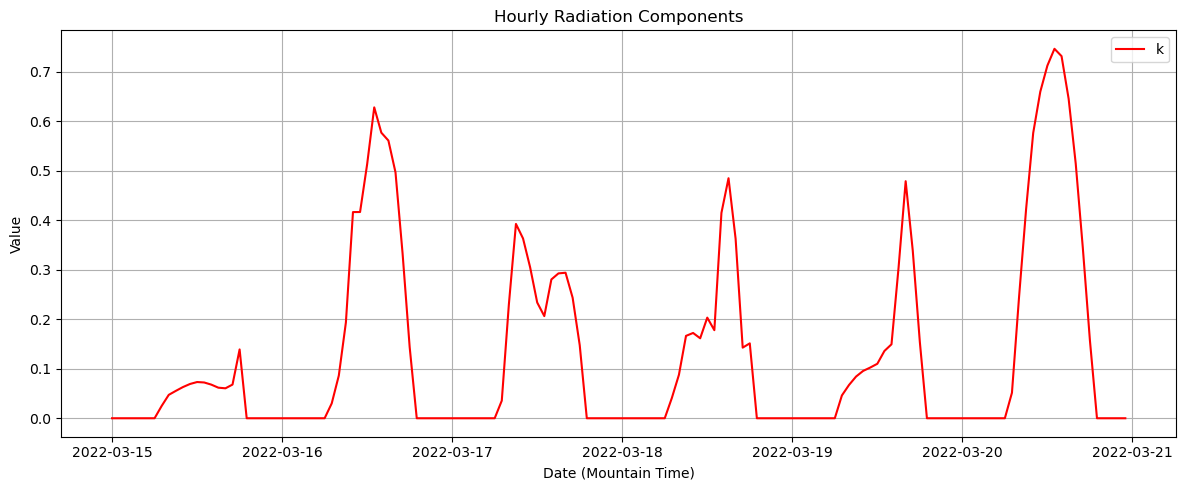

In [19]:
start = "2022-03-15"
end   = "2022-03-20"

subset_dif_sel  = subset_dif_local.sel(time_mt=slice(start, end))
subset_dir_sel  = subset_dir_local.sel(time_mt=slice(start, end))
subset_best_sel = subset_best_local.sel(time_mt=slice(start, end))
subset_k_sel = subset_m1_obs_k.sel(time_mt=slice(start, end))

dif = subset_dif_sel["down_short_diffuse_hemisp"].to_series()
dirr = subset_dir_sel["short_direct_normal"].to_series()
best = subset_best_sel["BestEstimate_down_short_hemisp"].to_series()
k_obs = subset_k_sel.to_series()

plt.figure(figsize=(12,5))

plt.plot(k_obs.index, k_obs.values, label="k", 
         color="red")

plt.xlabel("Date (Mountain Time)")
plt.ylabel("Value")
plt.title("Hourly Radiation Components")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
subset_zenith_hourly

<xarray.Dataset> Size: 188kB
Dimensions:  (time: 15672)
Coordinates:
  * time     (time) datetime64[ns] 125kB 2021-09-01 ... 2023-06-15T23:00:00
Data variables:
    zenith   (time) float32 63kB ...

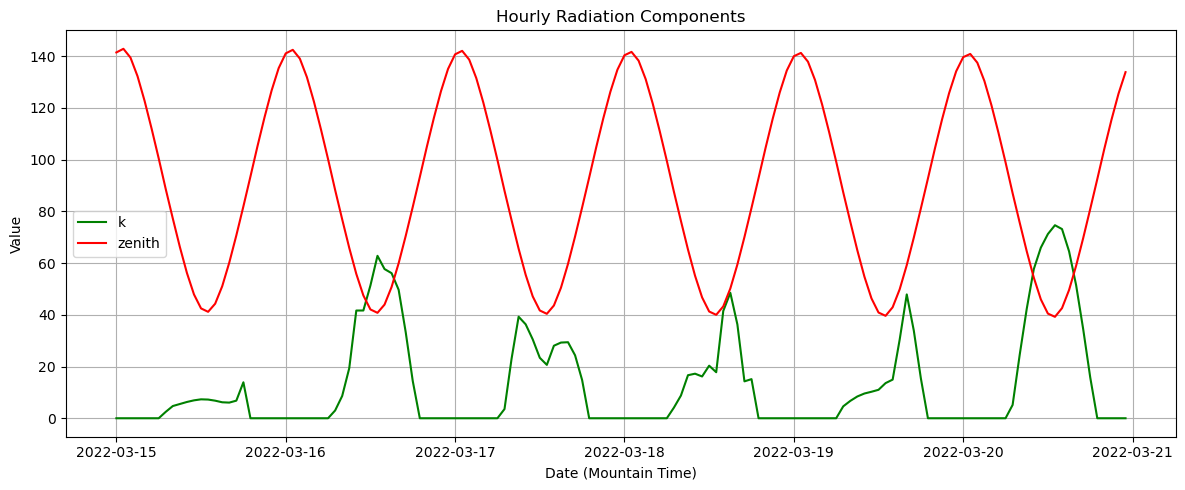

In [21]:
start = "2022-03-15"
end   = "2022-03-20"

subset_zen = to_local_mt(subset_zenith_hourly)
subset_zen_sel = subset_zen.sel(time_mt=slice(start, end))

zen = subset_zen_sel["zenith"].to_series()
k_obs = subset_k_sel.to_series() *100

plt.figure(figsize=(12,5))

plt.plot(k_obs.index, k_obs.values, label="k", color="green")
plt.plot(zen.index, zen.values, label="zenith", color="red")

plt.xlabel("Date (Mountain Time)")
plt.ylabel("Value")
plt.title("Hourly Radiation Components")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Separate based on average k value for the day to see variation in k by hour and zenith over months of the year

In [71]:
def to_local_mt(ds):
    # Convert to pandas datetime with timezone → then remove timezone
    mt = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
        .tz_localize(None)                       # <-- remove timezone
    )

    # Convert back to numpy datetime64 so xarray can use .dt
    mt_np = mt.to_numpy()

    return (
        ds.assign_coords(time_mt=("time", mt_np))
          .swap_dims({"time": "time_mt"})
          .drop_vars("time")
    )


subset_m1_obs_k = to_local_mt(m1_obs_k)

subset_m1_obs_k.time_mt.dt
subset_m1_obs_k.time_mt.dt.hour
# subset_m1_obs_k.time_mt.dt.day



<xarray.DataArray 'hour' (time_mt: 15672)> Size: 125kB
array([18, 19, 20, ..., 15, 16, 17])
Coordinates:
  * time_mt  (time_mt) datetime64[ns] 125kB 2021-08-31T18:00:00 ... 2023-06-1...

In [23]:
subset_m1_obs_k = to_local_mt(m1_obs_k)


subset_m1_obs_k = subset_m1_obs_k.assign_coords(
    hour=("time_mt", subset_m1_obs_k.time_mt.dt.hour.data)
)


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axi

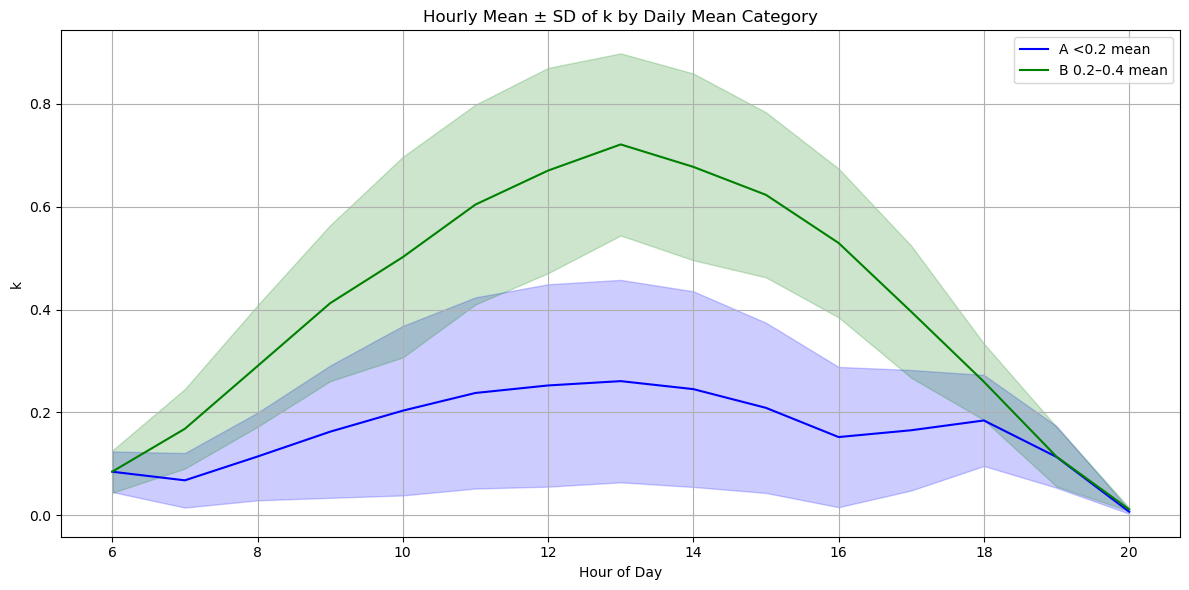

In [24]:
subset_m1_obs_k = to_local_mt(m1_obs_k)


subset_m1_obs_k = subset_m1_obs_k.assign_coords(
    hour=("time_mt", subset_m1_obs_k.time_mt.dt.hour.data)
)

daily_mean = subset_m1_obs_k.resample(time_mt="1D").mean()
daily_mean

daily_mean_series = daily_mean.to_series()

def categorize(val):
    if val < 0.2:
        return "A <0.2"
    elif val < 0.4:
        return "B 0.2–0.4"
    elif val < 0.6:
        return "C 0.4–0.6"
    else:
        return "D >0.6"

day_category = daily_mean_series.apply(categorize)

# Convert back to xarray for alignment
day_category_xr = xr.DataArray(
    day_category,
    coords=[daily_mean.time_mt],
    dims=["time_mt"]
)

# Broadcast from daily → hourly
subset_m1_obs_k = subset_m1_obs_k.assign_coords(
    day_type = day_category_xr.reindex(time_mt=subset_m1_obs_k.time_mt, method="ffill")
)

subset_nozero = subset_m1_obs_k.where(subset_m1_obs_k != 0)

# grouped = subset_m1_obs_k.groupby(("day_type", "hour"))
grouped = subset_nozero.groupby(("day_type", "hour"))


k_mean = grouped.mean()
k_std  = grouped.std()

mean_df = k_mean.to_series().unstack()   # rows = category, columns = 0–23
std_df  = k_std.to_series().unstack()

import matplotlib.pyplot as plt

categories = ["A <0.2", "B 0.2–0.4", "C 0.4–0.6", "D >0.6"]
colors = ["blue", "green", "orange", "red"]

plt.figure(figsize=(12,6))

for cat, col in zip(categories, colors):
    if cat in mean_df.index:
        plt.plot(mean_df.columns, mean_df.loc[cat], label=f"{cat} mean", color=col)
        plt.fill_between(
            mean_df.columns,
            mean_df.loc[cat] - std_df.loc[cat],
            mean_df.loc[cat] + std_df.loc[cat],
            color=col, alpha=0.2
        )

plt.legend()
plt.xlabel("Hour of Day")
plt.ylabel("k")
plt.title("Hourly Mean ± SD of k by Daily Mean Category")
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
subset_zenith = to_local_mt(subset_zenith_hourly)
subset_zenith.time_mt.dtype


dtype('<M8[ns]')

In [72]:
subset_zenith = to_local_mt(subset_zenith_hourly)

# Strip TZ if needed
# subset_zenith = subset_zenith.assign_coords(
#     time_mt=("time_mt", subset_zenith.time_mt.dt.hour.data)

subset_zenith = subset_zenith.assign_coords(
    hour=("time_mt", subset_zenith.time_mt.dt.hour.values)
)



subset_k, subset_z = xr.align(subset_m1_obs_k, subset_zenith, join="inner")

valid_mask = subset_z["zenith"] < 90
subset_k = subset_k.where(valid_mask)
subset_z = subset_z.where(valid_mask)

subset_k = subset_k.assign_coords(
    hour=("time_mt", subset_k.time_mt.dt.hour.data)
)

daily_mean = subset_k.resample(time_mt="1D").mean()
daily_mean_series = daily_mean.to_series()

def categorize(val):
    # return "A <0.2" if val < 0.2 else "B ≥0.2"
    return "Clear (mean_k < 0.2)" if val < 0.2 else "Cloudy (mean_k ≥ 0.2)"
    # return "Clear (mean_k < 0.1)" if val < 0.1 else "Cloudy (mean_k ≥ 0.1)"
    # "Clear (mean_k < 0.2)", "Cloudy (mean_k ≥ 0.2)"

day_category = daily_mean_series.apply(categorize)

day_type_xr = xr.DataArray(
    day_category,
    coords=[daily_mean.time_mt],
    dims=["time_mt"]
)

subset_k = subset_k.assign_coords(
    day_type = day_type_xr.reindex(time_mt=subset_k.time_mt, method="ffill")
)

grouped = subset_k.groupby(("day_type", "hour"))

k_mean = grouped.mean()
k_std  = grouped.std()

mean_df = k_mean.to_series().unstack()
std_df  = k_std.to_series().unstack()


/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/uufs/chpc.utah.edu/common/home/u1037042/software/pkg/miniconda3/envs/snow_viz/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axi

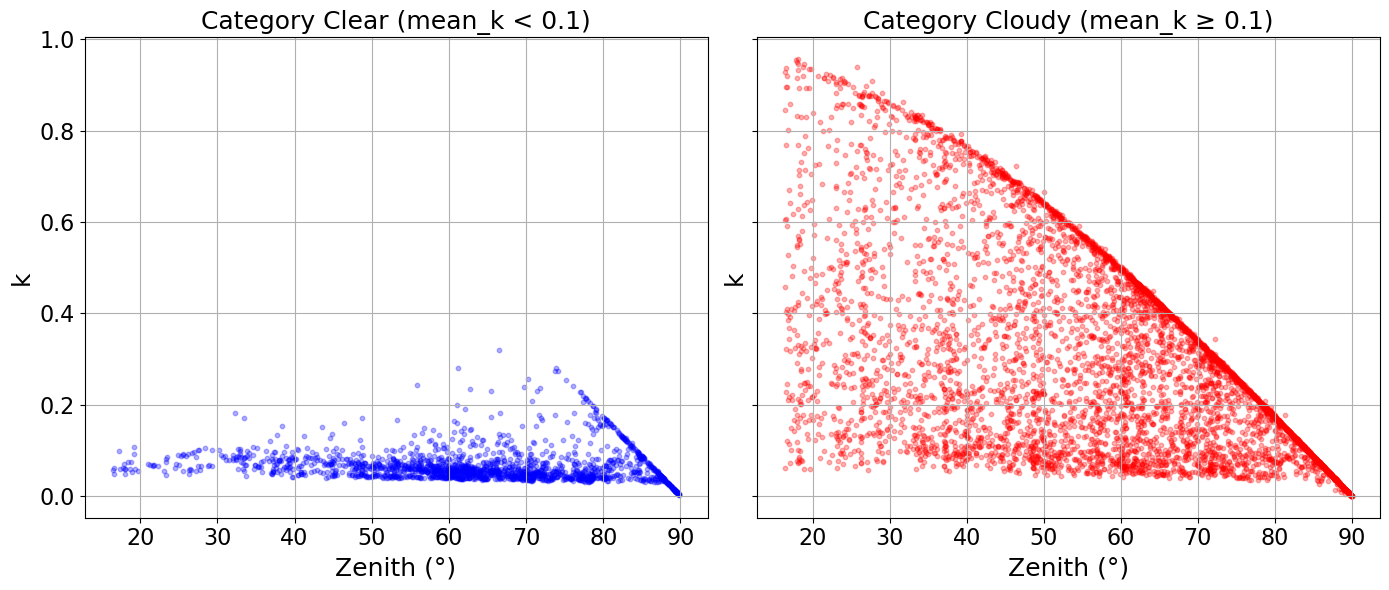

In [73]:
import matplotlib.pyplot as plt

# Align zenith to k
subset_z_aligned = subset_z.reindex(time_mt=subset_k.time_mt)

# Assign same day_type coordinate
subset_z_aligned = subset_z_aligned.assign_coords(
    day_type=subset_k.day_type
)

# Filter zenith > 90 (already done in valid_mask, but ensure)
subset_z_aligned = subset_z_aligned.where(subset_z_aligned < 90)

grouped_z = subset_z_aligned.groupby("day_type")
grouped_k = subset_k.groupby("day_type")

import numpy as np
import matplotlib.pyplot as plt

categories = ["Clear (mean_k < 0.2)", "Cloudy (mean_k ≥ 0.2)"]
# categories = ["Clear (mean_k < 0.1)", "Cloudy (mean_k ≥ 0.1)"]
colors = ["blue", "red"]

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

for ax, cat, col in zip(axes, categories, colors):
    # Select the variable inside the Dataset
    z_vals = grouped_z[cat]["zenith"].values.astype(float)
    k_vals = grouped_k[cat].values.astype(float)
    
    # Remove NaNs safely
    mask = (~np.isnan(z_vals)) & (~np.isnan(k_vals))
    z_vals = z_vals[mask]
    k_vals = k_vals[mask]
    
    ax.scatter(z_vals, k_vals, color=col, alpha=0.3, s=10)
    ax.set_title(f"Category {cat}", fontsize=18)
    ax.set_xlabel("Zenith (°)", fontsize=18)
    ax.set_ylabel("k", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(True)

# fig.suptitle("k vs Zenith by Daily Mean Category", fontsize=16)
plt.tight_layout()

plt.show()



In [40]:
subset_k_obs

<xarray.DataArray 'k' (time_mt: 7320)> Size: 29kB
array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)
Coordinates:
  * time_mt  (time_mt) object 59kB 1632981600000000000 ... 1659330000000000000

In [46]:
import numpy as np
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# 1. Define date range (forces all datasets to same period)
# -----------------------------------------------------------
start = "2021-12-01"
end   = "2022-05-01"

# Convert zenith dataset to local time
subset_zen = to_local_mt(subset_zenith_hourly)

# Subset all datasets to the same time range
subset_zen_sel    = subset_zen.sel(time_mt=slice(start, end))
subset_k_obs_sel  = subset_m1_obs_k.sel(time_mt=slice(start, end))
subset_k_mod_sel  = subset_m1_mod_k.sel(time_mt=slice(start, end))  # Dataset with ["k"]

# -----------------------------------------------------------
# 2. Apply zenith mask (< 90°) using NumPy array (duplicate-safe)
# -----------------------------------------------------------
valid_mask = (subset_zen_sel["zenith"] < 90).data  # NumPy mask prevents alignment

subset_k_obs = subset_k_obs_sel.where(valid_mask)
subset_k_mod = subset_k_mod_sel["k"].where(valid_mask)
subset_zen_masked = subset_zen_sel["zenith"].where(valid_mask)

# -----------------------------------------------------------
# 3. Assign hour + compute daily mean + categorize days
# -----------------------------------------------------------
subset_k_obs = subset_k_obs.assign_coords(
    hour=("time_mt", subset_k_obs.time_mt.dt.hour.data)
)

# Daily mean of observed k
daily_mean_k = subset_k_obs.resample(time_mt="1D").mean()

def categorize(val):
    return "Clear (mean_k < 0.2)" if val < 0.2 else "Cloudy (mean_k ≥ 0.2)"

day_category = daily_mean_k.to_series().apply(categorize)

# Convert back to DataArray and align to full series
day_type_xr = xr.DataArray(
    day_category,
    coords=[daily_mean_k.time_mt],
    dims=["time_mt"]
)

subset_k_obs = subset_k_obs.assign_coords(
    day_type = day_type_xr.reindex(time_mt=subset_k_obs.time_mt, method="ffill")
)

subset_k_mod = subset_k_mod.assign_coords(
    day_type = subset_k_obs.day_type
)

# -----------------------------------------------------------
# 4. Group by category
# -----------------------------------------------------------
grouped_obs = subset_k_obs.groupby("day_type")
grouped_mod = subset_k_mod.groupby("day_type")

categories = ["Clear (mean_k < 0.2)", "Cloudy (mean_k ≥ 0.2)"]
colors = ["blue", "red"]

# -----------------------------------------------------------
# 5. Plot observed vs modeled with regression stats
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15,6), sharey=True, sharex=True)

for ax, cat, col in zip(axes, categories, colors):

    obs_vals = grouped_obs[cat].values.astype(float)
    mod_vals = grouped_mod[cat].values.astype(float)

    # Remove NaNs
    mask = (~np.isnan(obs_vals)) & (~np.isnan(mod_vals))
    obs_vals = obs_vals[mask]
    mod_vals = mod_vals[mask]

    # Regression statistics
    if len(obs_vals) > 2:
        r, p = stats.pearsonr(obs_vals, mod_vals)
        slope, intercept, r_val, p_val, stderr = stats.linregress(obs_vals, mod_vals)
        r2 = r_val**2
    else:
        r = p = slope = r2 = np.nan

    # Scatter plot
    ax.scatter(obs_vals, mod_vals, color=col, alpha=0.3, s=10)
    ax.set_title(cat, fontsize=18)
    ax.set_xlabel("Observed k", fontsize=18)
    ax.set_ylabel("Modeled k", fontsize=18)
    ax.grid(True)

    # Add stats box
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}\n$R^2$ = {r2:.2f}\nslope = {slope:.2f}\np = {p:.3f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.tight_layout()
plt.show()


ValueError: cannot reindex or align along dimension 'time_mt' because the (pandas) index has duplicate values

In [51]:
daily_mean

<xarray.DataArray 'k' (floor: 152)> Size: 608B
array([0.04296129, 0.03524362, 0.03562213, 0.03636777, 0.05934867,
       0.20314436, 0.25075513, 0.2715153 , 0.2846596 , 0.2713308 ,
       0.04295626, 0.13034907, 0.10242964, 0.20741114, 0.27810913,
       0.08095072, 0.19073877, 0.04244127, 0.04101934, 0.04068286,
       0.04603861, 0.09732489, 0.27676195, 0.31151298, 0.22819252,
       0.27807173, 0.27730733, 0.2990815 , 0.3106794 , 0.31023428,
       0.30998403, 0.26032197, 0.09448925, 0.06249071, 0.26107797,
       0.32039472, 0.3175349 , 0.06261016, 0.32666826, 0.05335074,
       0.05133144, 0.08704106, 0.09979863, 0.10820186, 0.21864429,
       0.04846956, 0.05486246, 0.07080631, 0.18380614, 0.07362759,
       0.0492217 , 0.31775898, 0.04999163, 0.04869058, 0.15105645,
       0.313945  , 0.04866833, 0.30297008, 0.0482178 , 0.04647722,
       0.04696633, 0.13462682, 0.3317934 , 0.29686743, 0.07416014,
       0.05055116, 0.05251354, 0.05372087, 0.04643922, 0.05572261,
       0.2651518 , 0.16132428, 0.07655717, 0.07048213, 0.05026811,
       0.08012228, 0.2671836 , 0.34713426, 0.05748465, 0.07692169,
       0.05329999, 0.06254855, 0.41294587, 0.41544116, 0.39615715,
       0.29474512, 0.2829727 , 0.06275999, 0.06480096, 0.06264012,
       0.05899271, 0.07525782, 0.21116309, 0.409982  , 0.38618737,
       0.46193245, 0.33310187, 0.12958966, 0.46799392, 0.46637115,
       0.10552155, 0.07328764, 0.16062398, 0.08658832, 0.06666923,
       0.36585155, 0.25168014, 0.21353757, 0.17202179, 0.4835821 ,
       0.23295079, 0.20019239, 0.07644871, 0.09886388, 0.10265893,
       0.13119   , 0.11668519, 0.1277113 , 0.44069377, 0.3100973 ,
       0.25666696, 0.16448785, 0.3803424 , 0.49808758, 0.19993463,
       0.51593465, 0.08538465, 0.07789118, 0.08133788, 0.2907365 ,
       0.23235941, 0.5036012 , 0.49101713, 0.53629845, 0.52359146,
       0.46643302, 0.42136118, 0.5205023 , 0.12088343, 0.14004529,
       0.1186214 , 0.09934652, 0.34707513, 0.38271052, 0.32082027,
       0.20059836, 0.1837478 , 0.4599736 , 0.31614453, 0.31462288,
       0.09415889, 0.18038614], dtype=float32)
Coordinates:
  * floor    (floor) datetime64[ns] 1kB 2021-12-01 2021-12-02 ... 2022-05-01

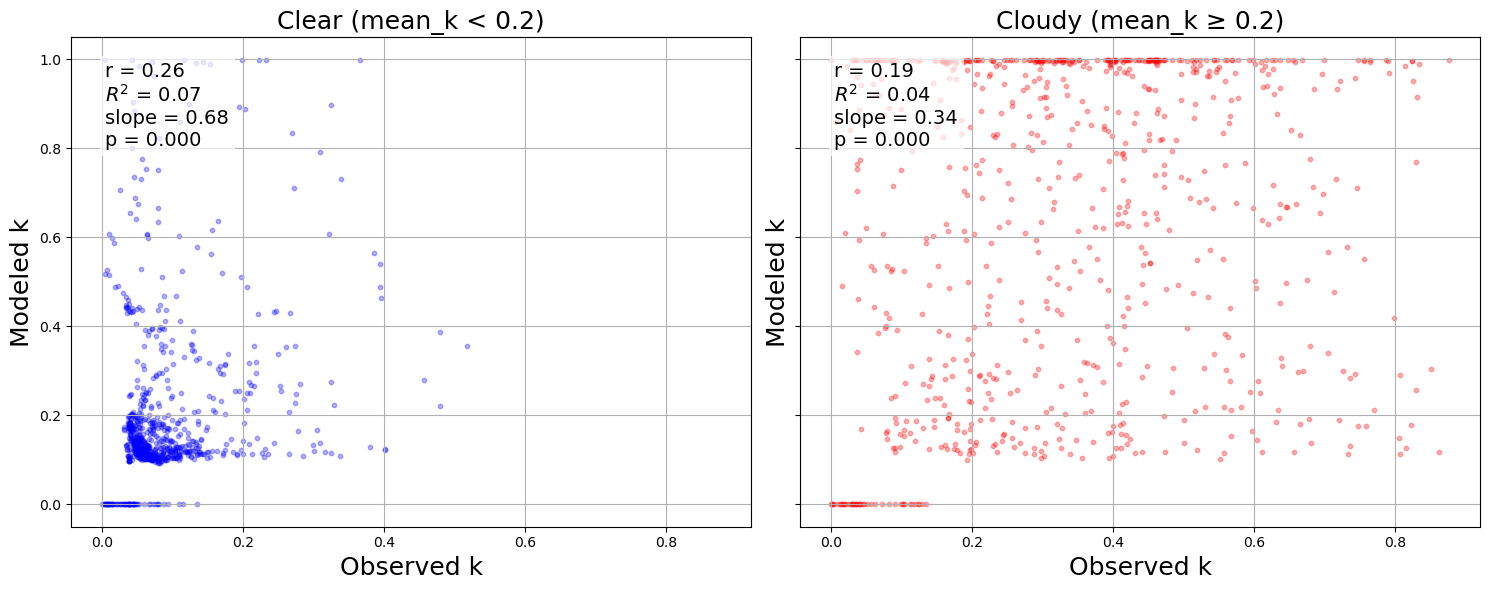

In [74]:
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# FIXED to_local_mt (no swap_dims!)
# -----------------------------------------------------------
def to_local_mt(ds):
    mt = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
        .tz_localize(None)
    )
    return ds.assign_coords(time_mt=("time", mt.to_numpy()))


# -----------------------------------------------------------
# 1. Convert all datasets to local MT
# -----------------------------------------------------------
subset_zen   = to_local_mt(subset_zenith_hourly)
subset_k_obs = to_local_mt(m1_obs_k)
subset_k_mod = to_local_mt(m1_k)   # dataset with ["k"]

# -----------------------------------------------------------
# 2. Subset using time_mt (which is a coordinate, not dimension)
# -----------------------------------------------------------
start = "2021-12-01"
end   = "2022-05-01"

def subset_timerange(ds):
    return ds.where(
        (ds.time_mt >= np.datetime64(start)) &
        (ds.time_mt <= np.datetime64(end)),
        drop=True
    )

subset_zen   = subset_timerange(subset_zen)
subset_k_obs = subset_timerange(subset_k_obs)
subset_k_mod = subset_timerange(subset_k_mod)

# -----------------------------------------------------------
# 3. Safe zenith mask (< 90°) using NUMPY MASK
# -----------------------------------------------------------
valid_mask = (subset_zen["zenith"] < 90).data   # NumPy array mask

k_obs = subset_k_obs.where(valid_mask)
k_mod = subset_k_mod["k"].where(valid_mask)
zen   = subset_zen["zenith"].where(valid_mask)

# -----------------------------------------------------------
# 4. Assign hour + categorize days based on obs k
# -----------------------------------------------------------
k_obs = k_obs.assign_coords(hour=("time", k_obs.time.dt.hour.data))

# Daily mean observed k
daily_mean = k_obs.groupby(k_obs.time.dt.floor("D")).mean()

def categorize(val):
    return "Clear (mean_k < 0.2)" if val < 0.2 else "Cloudy (mean_k ≥ 0.2)"

cat_series = daily_mean.to_series().apply(categorize)

# Reattach categories to full dataset
day_type_da = xr.DataArray(
    cat_series,
    coords=[daily_mean.floor],
    dims=["time"]
)

# Forward fill category per timestamp
day_type_full = day_type_da.reindex(time=k_obs.time, method="ffill")

k_obs = k_obs.assign_coords(day_type=day_type_full)
k_mod = k_mod.assign_coords(day_type=day_type_full)

# -----------------------------------------------------------
# 5. Plot observed vs modeled k by category with regression
# -----------------------------------------------------------
# categories = ["Clear (mean_k < 0.1)", "Cloudy (mean_k ≥ 0.1)"]
categories = ["Clear (mean_k < 0.2)", "Cloudy (mean_k ≥ 0.2)"]
colors = ["blue", "red"]

fig, axes = plt.subplots(1, 2, figsize=(15,6), sharex=True, sharey=True)

for ax, cat, col in zip(axes, categories, colors):

    obs_vals = k_obs.where(k_obs.day_type == cat).values.astype(float)
    mod_vals = k_mod.where(k_mod.day_type == cat).values.astype(float)

    mask = (~np.isnan(obs_vals)) & (~np.isnan(mod_vals))
    obs_vals = obs_vals[mask]
    mod_vals = mod_vals[mask]

    # Regression
    if len(obs_vals) > 3:
        slope, intercept, r_val, p_val, stderr = stats.linregress(obs_vals, mod_vals)
        r = r_val
        r2 = r_val**2
    else:
        slope = intercept = r = r2 = p_val = np.nan

    # Scatter plot
    ax.scatter(obs_vals, mod_vals, color=col, alpha=0.3, s=10)
    ax.set_title(cat, fontsize=18)
    ax.set_xlabel("Observed k", fontsize=18)
    ax.set_ylabel("Modeled k", fontsize=18)
    ax.grid(True)

    # Stats box
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}\n$R^2$ = {r2:.2f}\nslope = {slope:.2f}\np = {p_val:.3f}",
        transform=ax.transAxes,
        fontsize=14,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.tight_layout()
plt.show()


In [65]:
m1_obs_k.mean()

<xarray.DataArray 'k' ()> Size: 4B
array(0.11608589, dtype=float32)

# Compare measured and modeled k over a few days

In [28]:
def to_local_mt(ds):
    mt_time = (
        pd.to_datetime(ds.time.values)
        .tz_localize("UTC")
        .tz_convert("US/Mountain")
    )
    return (
        ds.assign_coords(time_mt=("time", mt_time))
          .swap_dims({"time": "time_mt"})
          .drop_vars("time")
    )

subset_m1_mod_k = to_local_mt(m1_k)
subset_m1_obs_k = to_local_mt(m1_obs_k)

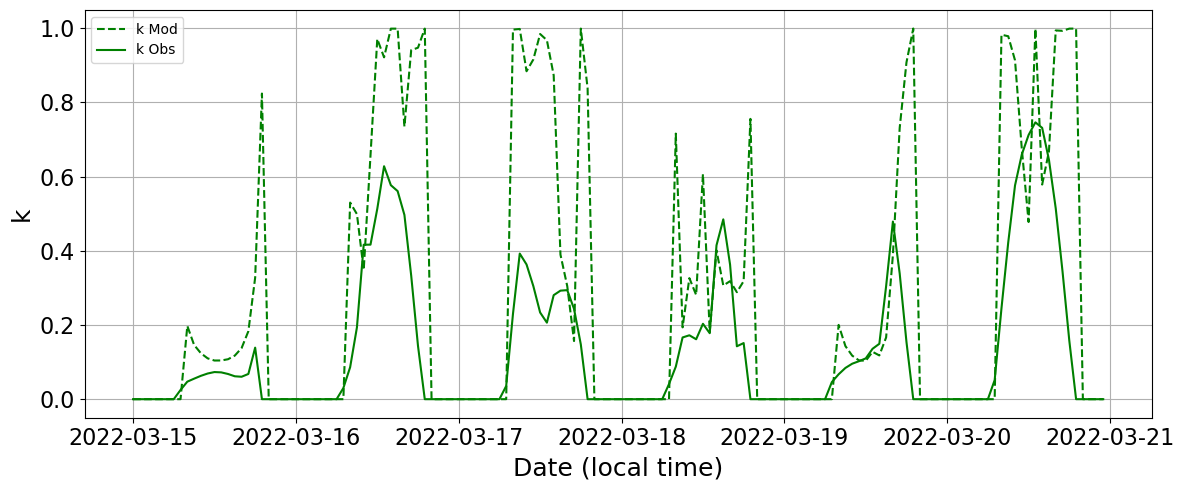

In [33]:
start = "2022-03-15"
end   = "2022-03-20"

subset_km_sel = subset_m1_mod_k.sel(time_mt=slice(start, end))
subset_ko_sel = subset_m1_obs_k.sel(time_mt=slice(start, end))

k_mod = subset_km_sel['k'].to_series()
k_obs = subset_ko_sel.to_series()

plt.figure(figsize=(12,5))

plt.plot(k_mod.index, k_mod.values, label="k Mod", color="green", linestyle='--')
plt.plot(k_obs.index, k_obs.values, label="k Obs", color="green")

plt.xlabel("Date (local time)", fontsize=18)
plt.ylabel("k", fontsize=18)
plt.tick_params(axis='both', labelsize=16)
# plt.title("Hourly Radiation Components")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Previous code and figures

Number of valid data points after dropping NaNs: 7304
Pearson Correlation: 0.611, p-value: 0.000e+00
                            OLS Regression Results                            
Dep. Variable:               observed   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     4355.
Date:                Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:42:01   Log-Likelihood:                 3700.3
No. Observations:                7304   AIC:                            -7397.
Df Residuals:                    7302   BIC:                            -7383.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

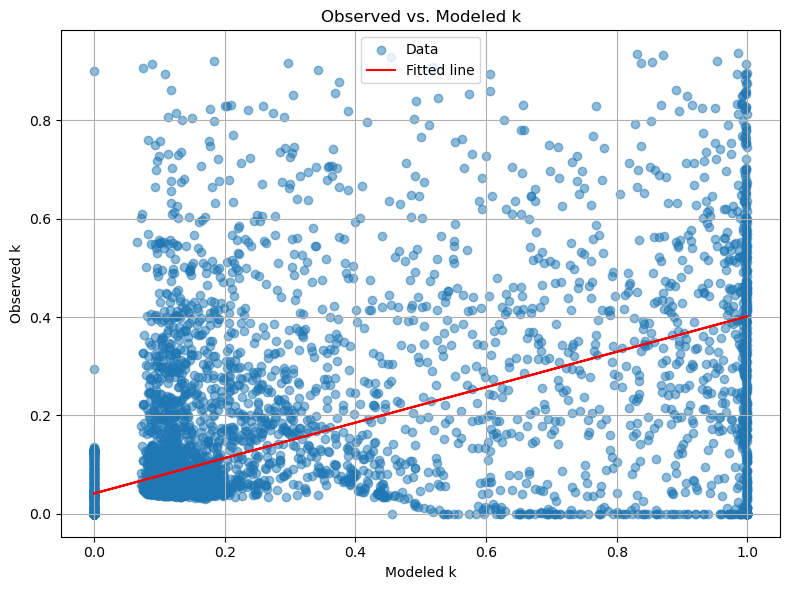

In [11]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import statsmodels.api as sm

# Step 1: Align datasets by overlapping time
start_time = max(m1_k.time.min().values, m1_obs_k.time.min().values)
end_time = min(m1_k.time.max().values, m1_obs_k.time.max().values)

m1_k_aligned = m1_k.sel(time=slice(start_time, end_time))
m1_obs_k_aligned = m1_obs_k.sel(time=slice(start_time, end_time))

# Step 2: Extract 'k' from modeled dataset
k_modeled = m1_k_aligned['k'].to_series()

# Step 3: Extract or define 'k' for observed dataset
# If 'k' is not present in m1_obs_k, define it manually like this:
# m1_obs_k['k'] = xr.DataArray(...)

# if 'k' not in m1_obs_k_aligned:
#     raise ValueError("Observed dataset (m1_obs_k) does not contain variable 'k'.")

k_observed = m1_obs_k_aligned.to_series()

# Step 4: Resample observed k to match modeled frequency (assumed hourly)
k_observed_resampled = k_observed.resample('h').mean()

# Step 5: Align by common time index
common_index = k_modeled.index.intersection(k_observed_resampled.index)
k_modeled_aligned = k_modeled.loc[common_index]
k_observed_aligned = k_observed_resampled.loc[common_index]

# Step 6: Remove missing values
df = pd.DataFrame({
    'modeled': k_modeled_aligned,
    'observed': k_observed_aligned
}).dropna()

# Check number of valid points
print(f"Number of valid data points after dropping NaNs: {len(df)}")

# Step 7: Correlation
corr, p_corr = pearsonr(df['modeled'], df['observed'])
print(f"Pearson Correlation: {corr:.3f}, p-value: {p_corr:.3e}")

# Step 8: Linear regression
X = sm.add_constant(df['modeled'])
model = sm.OLS(df['observed'], X).fit()
print(model.summary())

# Step 9: Plot
plt.figure(figsize=(8,6))
plt.scatter(df['modeled'], df['observed'], alpha=0.5, label='Data')
plt.plot(df['modeled'], model.predict(X), color='red', label='Fitted line')
plt.xlabel('Modeled k')
plt.ylabel('Observed k')
plt.title('Observed vs. Modeled k')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


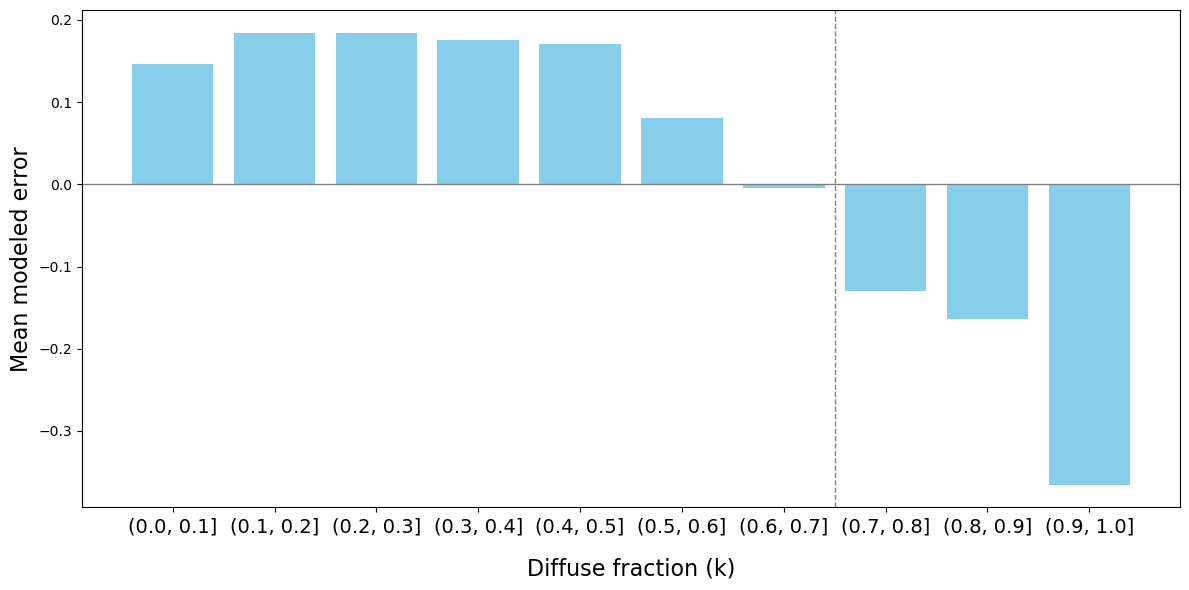

In [12]:
# Step 1: Compute absolute error
# df['abs_error'] = np.abs(df['modeled'] - df['observed'])
df['abs_error'] = (df['modeled'] - df['observed'])

# Step 2: Bin the observed k into 0.1 increments
df['k_bin'] = pd.cut(df['observed'], bins=np.arange(0, df['observed'].max() + 0.1, 0.1))

# Step 3: Group by bin and compute mean error
bin_error = df.groupby('k_bin', observed=True)['abs_error'].mean().reset_index()

# Step 4: Plot
plt.figure(figsize=(12,6))
plt.axhline(y=0, color='grey', linewidth=1)     # Horizontal line at y=0
plt.axvline(x=6.5, color='grey', linewidth=1, linestyle='--')    # Vertical line at x=6.5
plt.bar(bin_error['k_bin'].astype(str), bin_error['abs_error'], color='skyblue')
plt.xticks(rotation=0, fontsize=14)
plt.xlabel('Diffuse fraction (k)', fontsize=16, labelpad=15)
plt.ylabel('Mean modeled error', fontsize=16)
# plt.ylabel('Mean Absolute Error', fontsize=16)
plt.tight_layout()
plt.show()

# svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-figs-july-2025/"
# plt.savefig(svpth + 'k-bias-bar.png', dpi=300, bbox_inches='tight')

/scratch/local/u1037042/8594226/ipykernel_4035501/2971656601.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


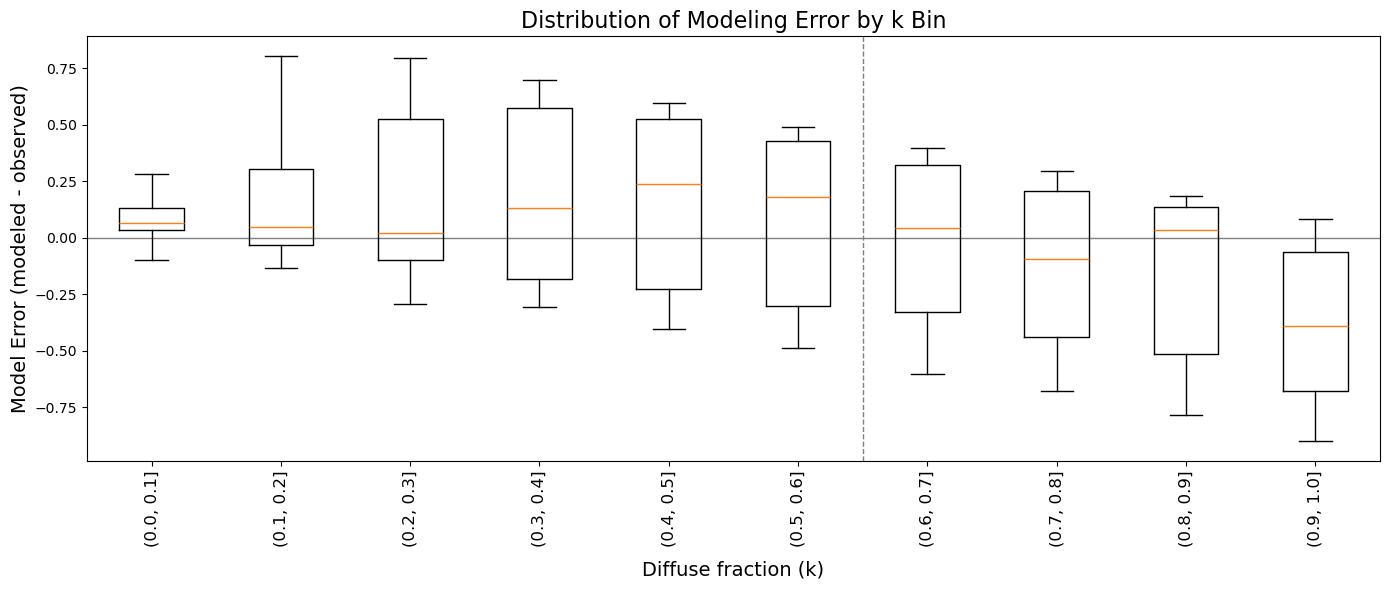

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calculate signed error (NOT absolute)
df['error'] = df['modeled'] - df['observed']

# Step 2: Bin the observed values into 0.1 increments
df['k_bin'] = pd.cut(df['observed'], bins=np.arange(0, df['observed'].max() + 0.1, 0.1))

# Step 3: Group by bins
grouped = df.groupby('k_bin', observed=True)['error']

# Step 4: Prepare data for boxplot
data = [group.dropna().values for _, group in grouped]
labels = [str(interval) for interval in grouped.groups.keys()]

# Step 5: Plot box and whiskers
plt.figure(figsize=(14,6))
plt.axhline(y=0, color='grey', linewidth=1)     # Horizontal reference line at y=0
plt.axvline(x=6.5, color='grey', linewidth=1, linestyle='--')  # Optional: vertical ref line

plt.boxplot(data, labels=labels, showfliers=False)
plt.xticks(rotation=90, fontsize=12)
plt.xlabel('Diffuse fraction (k)', fontsize=14, labelpad=10)
plt.ylabel('Model Error (modeled - observed)', fontsize=14)
plt.title('Distribution of Modeling Error by k Bin', fontsize=16)
plt.tight_layout()
plt.show()


/scratch/local/u1037042/8594226/ipykernel_4035501/3371954706.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, showfliers=False)


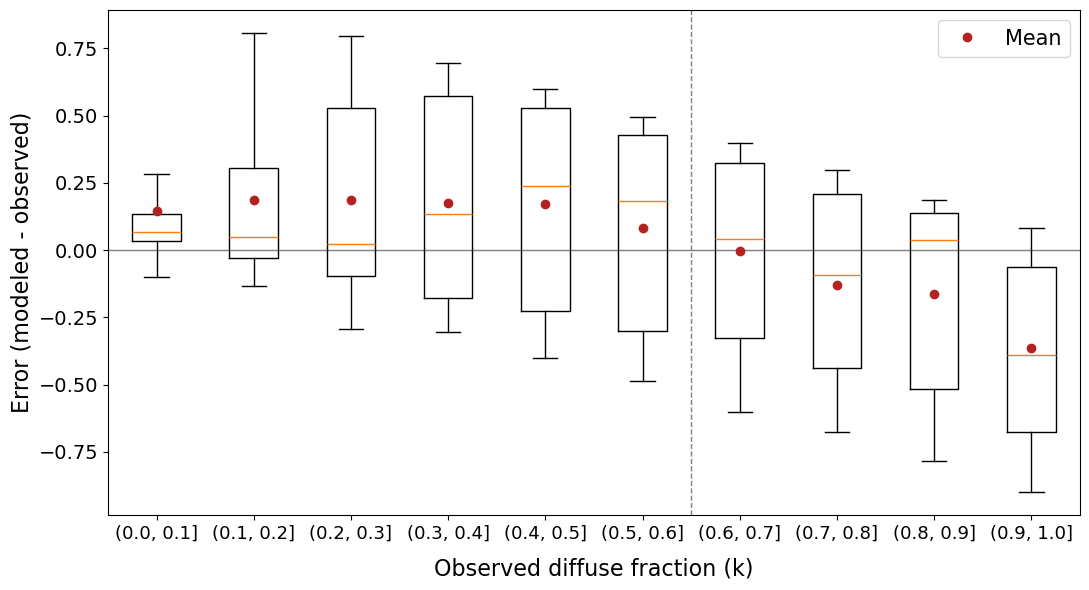

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calculate signed error
df['error'] = df['modeled'] - df['observed']

# Step 2: Bin the observed values into 0.1 increments
df['k_bin'] = pd.cut(df['observed'], bins=np.arange(0, df['observed'].max() + 0.1, 0.1))

# Step 3: Group by bins
grouped = df.groupby('k_bin', observed=True)['error']

# Step 4: Prepare data for boxplot and means
data = [group.dropna().values for _, group in grouped]
labels = [str(interval) for interval in grouped.groups.keys()]
means = [group.mean() for _, group in grouped]

# Step 5: Plot
plt.figure(figsize=(11,6))
plt.axhline(y=0, color='grey', linewidth=1)     # Horizontal reference line at y=0
plt.axvline(x=6.5, color='grey', linewidth=1, linestyle='--')  # Optional: vertical ref line

# Boxplot
box = plt.boxplot(data, labels=labels, showfliers=False)

# Overlay mean points
plt.plot(range(1, len(means)+1), means, color='firebrick', marker='o', linestyle='None', label='Mean')

# Final formatting
# plt.xticks(rotation=90, fontsize=12)
plt.xlabel('Observed diffuse fraction (k)', fontsize=16, labelpad=10)
plt.ylabel('Error (modeled - observed)', fontsize=16)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=14)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-sep/"
# plt.savefig(svpth + 'k-bias-dist.png', dpi=300, bbox_inches='tight')

/scratch/local/u1037042/8594226/ipykernel_4035501/3371954706.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, showfliers=False)


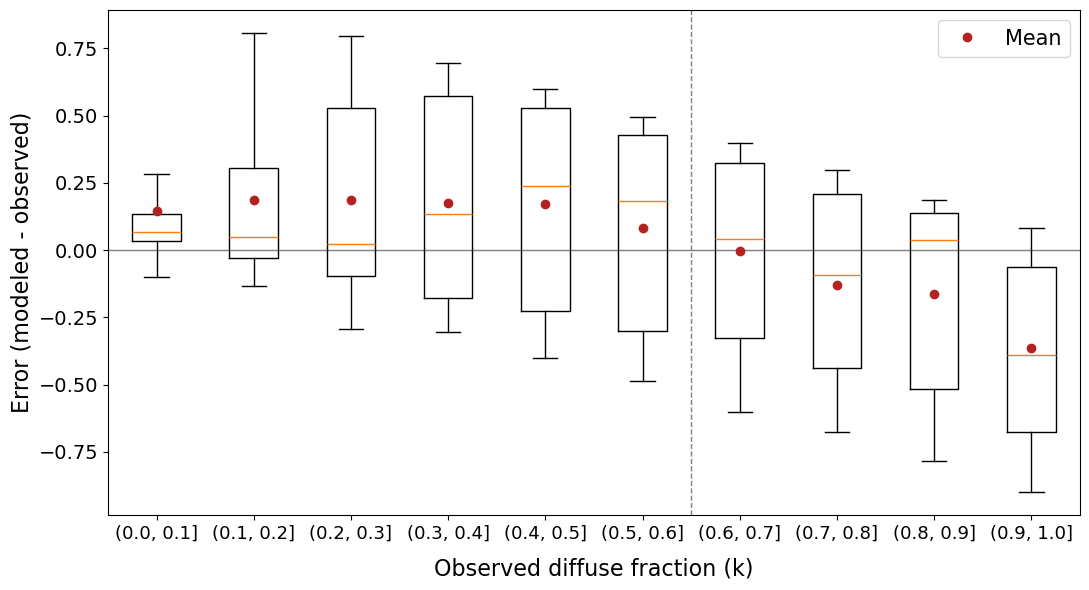

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Calculate signed error
df['error'] = df['modeled'] - df['observed']

# Step 2: Bin the observed values into 0.1 increments
df['k_bin'] = pd.cut(df['observed'], bins=np.arange(0, df['observed'].max() + 0.1, 0.1))

# Step 3: Group by bins
grouped = df.groupby('k_bin', observed=True)['error']

# Step 4: Prepare data for boxplot and means
data = [group.dropna().values for _, group in grouped]
labels = [str(interval) for interval in grouped.groups.keys()]
means = [group.mean() for _, group in grouped]

# Step 5: Plot
plt.figure(figsize=(11,6))
plt.axhline(y=0, color='grey', linewidth=1)     # Horizontal reference line at y=0
plt.axvline(x=6.5, color='grey', linewidth=1, linestyle='--')  # Optional: vertical ref line

# Boxplot
box = plt.boxplot(data, labels=labels, showfliers=False)

# Overlay mean points
plt.plot(range(1, len(means)+1), means, color='firebrick', marker='o', linestyle='None', label='Mean')

# Final formatting
# plt.xticks(rotation=90, fontsize=12)
plt.xlabel('Observed diffuse fraction (k)', fontsize=16, labelpad=10)
plt.ylabel('Error (modeled - observed)', fontsize=16)
plt.xticks(rotation=0, fontsize=13)
plt.yticks(fontsize=14)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

svpth = "/uufs/chpc.utah.edu/common/home/u1037042/Documents/figures-2025/isnobal-sep/"
# plt.savefig(svpth + 'k-bias-dist.png', dpi=300, bbox_inches='tight')


--- Stats for Modeled k < 0.6 (Clear) ---
Data points: 6249
Pearson Correlation: 0.608, p-value: 0.000e+00
                            OLS Regression Results                            
Dep. Variable:               observed   R-squared:                       0.370
Model:                            OLS   Adj. R-squared:                  0.370
Method:                 Least Squares   F-statistic:                     3670.
Date:                Wed, 19 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:42:20   Log-Likelihood:                 4676.4
No. Observations:                6249   AIC:                            -9349.
Df Residuals:                    6247   BIC:                            -9335.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------

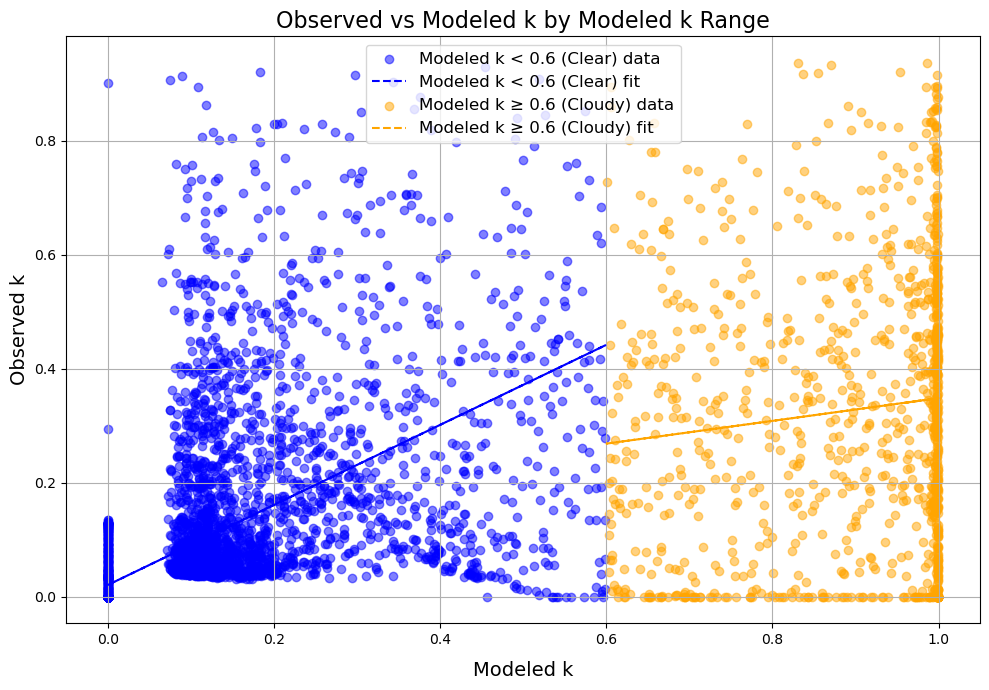

In [16]:
# --- Step 7: Split into two bins based on MODELED k ---
df_clear = df[df['modeled'] < 0.6]
df_cloudy = df[df['modeled'] >= 0.6]

def analyze_and_plot(subset, label, color):
    print(f"\n--- Stats for {label} ---")
    print(f"Data points: {len(subset)}")

    if len(subset) >= 2:
        corr, pval = pearsonr(subset['modeled'], subset['observed'])
        print(f"Pearson Correlation: {corr:.3f}, p-value: {pval:.3e}")
    else:
        print("Not enough data points for correlation.")
        return

    X = sm.add_constant(subset['modeled'])
    model = sm.OLS(subset['observed'], X).fit()
    print(model.summary())

    # Plot
    plt.scatter(subset['modeled'], subset['observed'], alpha=0.5, label=f'{label} data', color=color)
    plt.plot(subset['modeled'], model.predict(X), color=color, linestyle='--', label=f'{label} fit')

# --- Step 8–9: Plot both ---
plt.figure(figsize=(10, 7))

analyze_and_plot(df_clear, 'Modeled k < 0.6 (Clear)', 'blue')
analyze_and_plot(df_cloudy, 'Modeled k ≥ 0.6 (Cloudy)', 'orange')

plt.xlabel('Modeled k', fontsize=14, labelpad=10)
plt.ylabel('Observed k', fontsize=14)
plt.title('Observed vs Modeled k by Modeled k Range', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Split based on MODELED k instead of observed k
df_clear = df[df['modeled'] < 0.6]   # Clear conditions (lower modeled k)
df_cloudy = df[df['modeled'] >= 0.6] # Cloudy conditions (higher modeled k)




In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Step 1: Bin the modeled k into 0.1 increments
df['modeled_bin'] = pd.cut(df['modeled'], bins=np.arange(0, df['modeled'].max() + 0.1, 0.1))

# Step 2: Group by modeled_bin and compute correlation in each bin
correlations = []

for bin_interval, group in df.groupby('modeled_bin', observed=True):
    if len(group) >= 2:  # Pearson's r requires at least 2 points
        r, _ = pearsonr(group['modeled'], group['observed'])
    else:
        r = np.nan
    correlations.append({'modeled_bin': bin_interval, 'correlation': r})

# Step 3: Convert to DataFrame for plotting
corr_df = pd.DataFrame(correlations)

# Step 4: Plot
plt.figure(figsize=(10, 5))
plt.plot(corr_df['modeled_bin'].astype(str), corr_df['correlation'], marker='o', color='blue')
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.xticks(rotation=90)
plt.xlabel('Modeled k (binned)', fontsize=12)
plt.ylabel('Correlation (r)', fontsize=12)
plt.title('Correlation between Modeled and Observed k by Modeled Bin', fontsize=14)
plt.tight_layout()
plt.show()


### Observe relationship at time of day and under all sky conditions - should find patterns and standard biases